# Seminar 03: Classification Losses and MNIST Baseline

**Student Version**

Goals for today:
- Decode **binary**, **multi-class**, and **multi-label** classifier outputs
- Inspect **logits**, `softmax`, confidence, and top-2 margin
- Debug common loss/target mistakes
- Run a provided **MNIST MLP baseline**
- Compare one controlled model or optimizer change
- Analyze mistakes with a gallery, confusion matrix, and confidence scores

> Today is not about retyping the training loop. It is about understanding classifier outputs and debugging classification behavior.


## 0. Setup


In [1]:
import math
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

### Helpers


In [2]:
def show_images(images, titles=None, nrow=8, figsize=(10, 4)):
    """Display a small batch of MNIST images. images: tensor [N, 1, 28, 28]."""
    images = images.detach().cpu()
    n = images.shape[0]
    ncol = int(math.ceil(n / nrow))
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(ncol, nrow, i + 1)
        plt.imshow(images[i, 0], cmap="gray")
        plt.axis("off")
        if titles is not None:
            plt.title(str(titles[i]), fontsize=8)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def accuracy_multiclass(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()


def print_contract_table(rows):
    header = f"{'case':<24} {'task':<13} {'loss':<22} {'valid':<7} fix/remark"
    print(header)
    print('-' * len(header))
    for row in rows:
        print(
            f"{row['case']:<24} {row['task']:<13} {row['loss']:<22} "
            f"{str(row['valid']):<7} {row['fix']}"
        )


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    y_true_parts = []
    y_pred_parts = []
    prob_parts = []
    image_parts = []

    for xb, yb in loader:
        xb_device = xb.to(device)
        logits = model(xb_device)
        probs = F.softmax(logits, dim=1).cpu()
        preds = probs.argmax(dim=1)

        image_parts.append(xb.cpu())
        y_true_parts.append(yb.cpu())
        y_pred_parts.append(preds.cpu())
        prob_parts.append(probs)

    return {
        'images': torch.cat(image_parts),
        'y_true': torch.cat(y_true_parts),
        'y_pred': torch.cat(y_pred_parts),
        'probs': torch.cat(prob_parts),
    }


def make_confusion_matrix(y_true, y_pred, num_classes=10):
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    for true_label, pred_label in zip(y_true.tolist(), y_pred.tolist()):
        confusion[true_label, pred_label] += 1
    return confusion


def plot_confusion_matrix(confusion, title='Confusion matrix'):
    plt.figure(figsize=(6, 5))
    plt.imshow(confusion.numpy(), cmap='Blues')
    plt.title(title)
    plt.xlabel('predicted')
    plt.ylabel('true')
    plt.xticks(range(10))
    plt.yticks(range(10))
    plt.colorbar()
    plt.show()


## 1. Prediction decoder lab

Before choosing a loss, first understand what a model output means.

### Exercise 1.1
You are given logits from three classifiers:
- binary: one yes/no decision per object
- multi-class: exactly one class per object
- multi-label: several labels may be active for one object

Decode each output into human-readable predictions.

Tasks:
- convert binary logits to probabilities and 0/1 predictions
- convert multi-class logits to probabilities, class ids, and class names
- convert multi-label logits to probabilities and active label names using threshold `0.5`
- print the decoded predictions clearly

Useful function hints:
- `torch.sigmoid(logits)` converts independent binary/multi-label logits to probabilities.
- `F.softmax(logits, dim=1)` converts multi-class logits to competing class probabilities.
- `tensor.argmax(dim=1)` returns the winning class index for each row.


In [14]:
# Exercise 1.1

binary_logits = torch.tensor([-2.0, 0.3, 1.8, -0.1])
binary_names = ['not spam', 'spam']

multiclass_logits = torch.tensor([
    [2.0, 0.5, -1.0],
    [0.1, 2.5, 0.3],
    [1.0, 1.1, 1.2],
])
multiclass_names = ['cat', 'dog', 'car']

multilabel_logits = torch.tensor([
    [2.0, -1.0, 0.8, -0.3],
    [-0.5, 1.2, 2.1, -2.0],
    [0.1, 0.2, -0.4, 1.8],
])
multilabel_names = ['indoor', 'animal', 'vehicle', 'night']

binary_probs = torch.sigmoid(binary_logits)
binary_pred = (binary_probs >= 0.5).long()
# [names[obj] for obj in arr]
binary_decoded = [binary_names[i] for i in binary_pred]

multiclass_probs = F.softmax(multiclass_logits, dim=1)
multiclass_pred = multiclass_probs.argmax(dim=1)
multiclass_decoded = [multiclass_names[i] for i in multiclass_pred]

multilabel_probs = torch.sigmoid(multilabel_logits)
multilabel_pred = multilabel_probs >= 0.5
#multilabel_decoded = [names[obj] for obj in multilabel_pred]
multilabel_decoded = []
for i in multilabel_pred:
  label = []
  for idx, j in enumerate(i):
    if j:
      label.append(multilabel_names[idx])

  multilabel_decoded.append(label)




# Fill the variables above.
# Hint: binary and multi-label outputs use sigmoid; multi-class output uses softmax over dim=1.
# binary_decoded should be a list of label names.
# multiclass_decoded should be a list of class names.
# multilabel_decoded should be a list of lists with active label names.

print('binary probabilities:', binary_probs)
print('binary decoded:', binary_decoded)
print('multiclass probabilities:', multiclass_probs)
print('multiclass decoded:', multiclass_decoded)
print('multilabel probabilities:', multilabel_probs)
print('multilabel decoded:', multilabel_decoded)
print(multilabel_pred)


binary probabilities: tensor([0.1192, 0.5744, 0.8581, 0.4750])
binary decoded: ['not spam', 'spam', 'spam', 'not spam']
multiclass probabilities: tensor([[0.7856, 0.1753, 0.0391],
        [0.0755, 0.8323, 0.0922],
        [0.3006, 0.3322, 0.3672]])
multiclass decoded: ['cat', 'dog', 'car']
multilabel probabilities: tensor([[0.8808, 0.2689, 0.6900, 0.4256],
        [0.3775, 0.7685, 0.8909, 0.1192],
        [0.5250, 0.5498, 0.4013, 0.8581]])
multilabel decoded: [['indoor', 'vehicle'], ['animal', 'vehicle'], ['indoor', 'animal', 'night']]
tensor([[ True, False,  True, False],
        [False,  True,  True, False],
        [ True,  True, False,  True]])


### Checks (Exercise 1.1)


In [ ]:
assert binary_probs.shape == binary_logits.shape
assert binary_pred.tolist() == [0, 1, 1, 0]
assert binary_decoded == ['not spam', 'spam', 'spam', 'not spam']

assert multiclass_probs.shape == multiclass_logits.shape
assert torch.allclose(multiclass_probs.sum(dim=1), torch.ones(multiclass_logits.shape[0]), atol=1e-6)
assert multiclass_pred.tolist() == [0, 1, 2]
assert multiclass_decoded == ['cat', 'dog', 'car']

assert multilabel_probs.shape == multilabel_logits.shape
assert multilabel_pred.dtype == torch.bool
assert multilabel_pred.shape == multilabel_logits.shape
assert multilabel_decoded == [
    ['indoor', 'vehicle'],
    ['animal', 'vehicle'],
    ['indoor', 'animal', 'night'],
]
print('Exercise 1.1 checks passed.')


## 2. Logits, softmax, confidence, and top-2 margin

A classifier returns logits. We often convert them to probabilities for interpretation, but the largest logit and largest probability give the same predicted class.


In [15]:
seed_everything(7)
logits_small = torch.tensor([
    [4.0, 0.2, -1.0, 0.1],
    [0.9, 1.1, 1.0, -0.5],
    [-1.0, -0.8, 3.2, 0.0],
    [2.0, 1.9, 1.8, 1.7],
])
class_names = ['cat', 'dog', 'car', 'tree']
logits_small


tensor([[ 4.0000,  0.2000, -1.0000,  0.1000],
        [ 0.9000,  1.1000,  1.0000, -0.5000],
        [-1.0000, -0.8000,  3.2000,  0.0000],
        [ 2.0000,  1.9000,  1.8000,  1.7000]])

### Exercise 2.1
Compute:
- probabilities with `softmax`
- predicted class ids
- confidence for each row
- top-2 classes and the top-1 minus top-2 probability margin
- the most ambiguous row

Print one compact line per example.

Useful function hints:
- `F.softmax(logits, dim=1)` normalizes across classes.
- `probs.max(dim=1)` gives confidence values and winning indices.
- `probs.topk(k=2, dim=1)` gives the top-2 probabilities and class ids per row.


In [26]:
# Exercise 2.1
print(logits_small)
probs_small = F.softmax(logits_small, dim=1)
print(probs_small)
confidence = probs_small.max(dim=1).values
pred_ids = probs_small.max(dim=1).indices
print(666, confidence)

top2_probs, top2_ids = probs_small.topk(k=2, dim=1)
print(777, top2_probs, top2_ids)
margin = top2_probs[:, 0] - top2_probs[:, 1]
print(margin)
most_ambiguous_row = margin.argmin()
print(most_ambiguous_row)

# Fill the variables above, then print a compact report.
# Hint: top2_probs[:, 0] - top2_probs[:, 1] is the top-2 margin.

print('pred_ids:', pred_ids)
print('confidence:', confidence)
print('top2_ids:', top2_ids)
print('margin:', margin)
print('most ambiguous row:', most_ambiguous_row)


tensor([[ 4.0000,  0.2000, -1.0000,  0.1000],
        [ 0.9000,  1.1000,  1.0000, -0.5000],
        [-1.0000, -0.8000,  3.2000,  0.0000],
        [ 2.0000,  1.9000,  1.8000,  1.7000]])
tensor([[0.9530, 0.0213, 0.0064, 0.0193],
        [0.2799, 0.3418, 0.3093, 0.0690],
        [0.0140, 0.0171, 0.9310, 0.0380],
        [0.2887, 0.2612, 0.2363, 0.2138]])
666 tensor([0.9530, 0.3418, 0.9310, 0.2887])
777 tensor([[0.9530, 0.0213],
        [0.3418, 0.3093],
        [0.9310, 0.0380],
        [0.2887, 0.2612]]) tensor([[0, 1],
        [1, 2],
        [2, 3],
        [0, 1]])
tensor([0.9317, 0.0325, 0.8931, 0.0275])
tensor(3)
pred_ids: tensor([0, 1, 2, 0])
confidence: tensor([0.9530, 0.3418, 0.9310, 0.2887])
top2_ids: tensor([[0, 1],
        [1, 2],
        [2, 3],
        [0, 1]])
margin: tensor([0.9317, 0.0325, 0.8931, 0.0275])
most ambiguous row: tensor(3)


### Checks (Exercise 2.1)


In [27]:
assert probs_small.shape == logits_small.shape
assert torch.allclose(probs_small.sum(dim=1), torch.ones(logits_small.shape[0]), atol=1e-6)
assert torch.equal(pred_ids, logits_small.argmax(dim=1))
assert top2_ids.shape == (logits_small.shape[0], 2)
assert int(most_ambiguous_row) == int(margin.argmin())
print('Exercise 2.1 checks passed.')


Exercise 2.1 checks passed.


## 3. Loss bug hunt

### Exercise 3.1
For each loss call, decide whether it is:
- `valid`: correct input contract for the intended task
- `errors`: PyTorch should reject it
- `runs_but_wrong`: PyTorch can compute a number, but the input contract is wrong for training

You only fill the verdicts. The check cell will run the actual loss functions and verify whether your verdict matches their behavior.


In [33]:
seed_everything(11)
mc_logits = torch.randn(5, 4)
mc_targets = torch.tensor([0, 2, 1, 3, 2], dtype=torch.long)
mc_targets_column = mc_targets.reshape(-1, 1)

binary_logits = torch.randn(5)
binary_targets_float = torch.tensor([0, 1, 1, 0, 1], dtype=torch.float32)
binary_targets_long = binary_targets_float.long()

multilabel_logits = torch.randn(5, 3)
multilabel_targets = torch.tensor([
    [1, 0, 1],
    [0, 1, 0],
    [1, 1, 0],
    [0, 0, 1],
    [1, 0, 0],
], dtype=torch.float32)


In [30]:
# Exercise 3.1

loss_cases = [
    {'name': 'ce_correct_logits', 'verdict': 'valid'},
    {'name': 'ce_wrong_softmax_input', 'verdict': 'runs_but_wrong'},
    {'name': 'ce_wrong_target_shape', 'verdict': 'errors'},
    {'name': 'bce_correct_float_target', 'verdict': 'valid'},
    {'name': 'bce_wrong_long_target', 'verdict': 'errors'},
    {'name': 'bce_correct_multilabel', 'verdict': 'valid'},
]

for row in loss_cases:
    print(row)


{'name': 'ce_wrong_softmax_input', 'verdict': 'runs_but_wrong'}
{'name': 'ce_wrong_target_shape', 'verdict': 'errors'}
{'name': 'bce_correct_float_target', 'verdict': 'valid'}
{'name': 'bce_wrong_long_target', 'verdict': 'errors'}
{'name': 'bce_correct_multilabel', 'verdict': 'valid'}


### Checks (Exercise 3.1)


In [31]:
def _run_loss_case(fn):
    try:
        value = fn()
        return {'ran': True, 'loss': float(value.item()), 'error_type': None}
    except Exception as exc:
        return {'ran': False, 'loss': None, 'error_type': type(exc).__name__}


def _is_finite_loss(result):
    return result['ran'] and result['loss'] is not None and math.isfinite(result['loss'])


case_fns = {
    'ce_correct_logits': lambda: F.cross_entropy(mc_logits, mc_targets),
    'ce_wrong_softmax_input': lambda: F.cross_entropy(F.softmax(mc_logits, dim=1), mc_targets),
    'ce_wrong_target_shape': lambda: F.cross_entropy(mc_logits, mc_targets_column),
    'bce_correct_float_target': lambda: F.binary_cross_entropy_with_logits(binary_logits, binary_targets_float),
    'bce_wrong_long_target': lambda: F.binary_cross_entropy_with_logits(binary_logits, binary_targets_long),
    'bce_correct_multilabel': lambda: F.binary_cross_entropy_with_logits(multilabel_logits, multilabel_targets),
}

student_verdicts = {row['name']: row['verdict'] for row in loss_cases}
assert set(student_verdicts) == set(case_fns), 'Keep the original case names.'
assert all(verdict in {'valid', 'errors', 'runs_but_wrong'} for verdict in student_verdicts.values())

observed = {name: _run_loss_case(fn) for name, fn in case_fns.items()}

for name, verdict in student_verdicts.items():
    result = observed[name]
    if verdict == 'valid':
        assert _is_finite_loss(result), f'{name}: marked valid, but the loss did not run cleanly.'
    elif verdict == 'errors':
        assert not result['ran'], f'{name}: marked errors, but PyTorch computed a loss.'
    elif verdict == 'runs_but_wrong':
        assert _is_finite_loss(result), f'{name}: marked runs_but_wrong, but it did not run.'

# Extra behavioral check for the important subtle case:
# softmax does not change argmax, but it changes the CE loss input contract and value.
assert student_verdicts['ce_wrong_softmax_input'] == 'runs_but_wrong'
assert torch.equal(mc_logits.argmax(dim=1), F.softmax(mc_logits, dim=1).argmax(dim=1))
assert abs(observed['ce_correct_logits']['loss'] - observed['ce_wrong_softmax_input']['loss']) > 1e-4

print('Observed behavior:')
for name, result in observed.items():
    print(name, result)
print('Exercise 3.1 checks passed.')


AssertionError: Keep the original case names.

### Observation: what `CrossEntropyLoss` does internally
`CrossEntropyLoss(logits, y)` is equivalent to `log_softmax(logits)` followed by selecting the correct class negative log-probability. This is why raw logits are the correct input.


In [34]:
ce_direct = F.cross_entropy(mc_logits, mc_targets)
log_probs = F.log_softmax(mc_logits, dim=1)
ce_manual = -log_probs[torch.arange(len(mc_targets)), mc_targets].mean()
print('direct CE:', ce_direct.item())
print('manual CE:', ce_manual.item())
print('match:', torch.allclose(ce_direct, ce_manual))


direct CE: 1.8339836597442627
manual CE: 1.8339834213256836
match: True


## 4. MNIST data and batch inspection

The train/validation split is already prepared. Your job is to inspect whether the tensors and labels match the multi-class contract.


In [35]:
transform = transforms.Compose([transforms.ToTensor()])

train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_full = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_n = 12000
val_n = 2000

seed_everything(42)
perm = torch.randperm(len(train_full))
val_idx = perm[:val_n]
train_idx = perm[val_n:val_n + train_n]

train_ds = Subset(train_full, train_idx.tolist())
val_ds = Subset(train_full, val_idx.tolist())

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.14MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.45MB/s]


(12000, 2000)

### Exercise 4.1
Run a small MNIST data sanity audit before training.

Helper contract you may use here:

```python
show_images(images, titles=None, nrow=8, figsize=(10, 4))
```

- `images`: tensor with shape `[N, 1, 28, 28]`
- `titles`: optional list of `N` labels/strings
- `nrow`: how many images to put in one row

Tasks:
- inspect one batch: shapes, dtypes, pixel min/max
- visualize 16 images with their labels
- compute class counts for both train and validation subsets as tensors of shape `[10]`
- plot train vs validation class counts side by side
- compute the validation majority-class baseline accuracy
- compute the random-guess baseline accuracy for 10 classes

Question: is a 90% validation accuracy meaningful compared with these baselines?


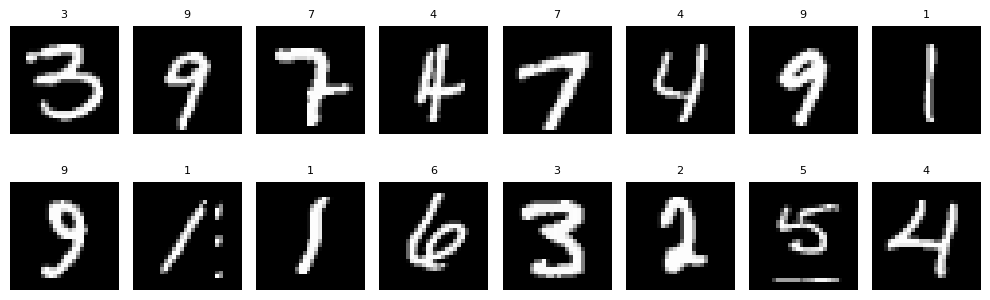

batch_shape: torch.Size([128, 1, 28, 28])
label_shape: torch.Size([128])
image_dtype: torch.float32
label_dtype: torch.int64
pixel range: tensor(0.) tensor(1.)
train_counts: tensor([1192, 1320, 1208, 1234, 1190, 1075, 1205, 1216, 1177, 1183])
val_counts: tensor([201, 213, 187, 202, 197, 195, 212, 203, 207, 183])
majority_class: tensor(1)
majority_val_accuracy: 0.1065
random_guess_accuracy: 0.1


In [38]:
# Exercise 4.1

xb, yb = next(iter(train_loader))

batch_shape = xb.shape
label_shape = yb.shape
image_dtype = xb.dtype
label_dtype = yb.dtype
pixel_min = xb.min()
pixel_max = xb.max()

train_labels = torch.tensor([train_full.targets[i] for i in train_idx.tolist()], dtype=torch.long)
val_labels = torch.tensor([train_full.targets[i] for i in val_idx.tolist()], dtype=torch.long)

train_counts = torch.bincount(train_labels, minlength=10)
val_counts = torch.bincount(val_labels, minlength=10)

# train_counts = torch.bincount(train_labels, minlengh=10) # expected: torch tensor with shape [10]
# val_counts = torch.bincount(val_labels, minleght=10)    # expected: torch tensor with shape [10]
majority_class = val_counts.argmax()
majority_val_accuracy = float(val_counts.max().item() / val_counts.sum().item())
random_guess_accuracy = 1 / 10

show_images(xb[:16], titles=yb[:16].tolist(), nrow=8, figsize=(10, 3.5))


# Fill the variables above.
# Hint for class counts: torch.bincount(labels, minlength=10) counts labels 0..9.
# Then visualize 16 images and plot train/validation class counts side by side.

print('batch_shape:', batch_shape)
print('label_shape:', label_shape)
print('image_dtype:', image_dtype)
print('label_dtype:', label_dtype)
print('pixel range:', pixel_min, pixel_max)
print('train_counts:', train_counts)
print('val_counts:', val_counts)
print('majority_class:', majority_class)
print('majority_val_accuracy:', majority_val_accuracy)
print('random_guess_accuracy:', random_guess_accuracy)


### Checks (Exercise 4.1)


In [39]:
assert batch_shape == (128, 1, 28, 28)
assert label_shape == (128,)
assert image_dtype == torch.float32
assert label_dtype == torch.int64
assert 0.0 <= pixel_min <= pixel_max <= 1.0

assert train_counts.shape == (10,)
assert val_counts.shape == (10,)
assert int(train_counts.sum().item()) == len(train_ds)
assert int(val_counts.sum().item()) == len(val_ds)

assert 0 <= majority_class <= 9
assert 0.08 <= majority_val_accuracy <= 0.20
assert random_guess_accuracy == 0.1
print('Exercise 4.1 checks passed.')


Exercise 4.1 checks passed.


## 5. Baseline runner and one controlled change

The training helpers are provided. Read them, then run a baseline and one controlled change. Do not rewrite the loop today.

Helper contracts you will use here:

```python
run_experiment(name, hidden_dim=256, activation="relu", lr=1e-3, epochs=5) -> dict
plot_histories(results, metric="val_acc", title=None)
```

`run_experiment` returns a dictionary with keys `name`, `model`, `history`, and `elapsed`. The `history` value contains lists such as `history["val_acc"]` and `history["val_loss"]`.


In [ ]:
def make_mlp(hidden_dim=256, activation='relu'):
    activations = {
        'relu': nn.ReLU,
        'tanh': nn.Tanh,
        'sigmoid': nn.Sigmoid,
    }
    if activation not in activations:
        raise ValueError(f'Unknown activation: {activation}')
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, hidden_dim),
        activations[activation](),
        nn.Linear(hidden_dim, 10),
    ).to(device)


def make_optimizer(model, lr=1e-3):
    return torch.optim.Adam(model.parameters(), lr=lr)


def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = loss_fn(logits, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()

        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits.detach(), yb) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = loss_fn(logits, yb)

        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits, yb) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


def run_experiment(name, hidden_dim=256, activation='relu', lr=1e-3, epochs=5):
    seed_everything(123)
    model = make_mlp(hidden_dim=hidden_dim, activation=activation)
    loss_fn = nn.CrossEntropyLoss()
    opt = make_optimizer(model, lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, loss_fn)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        print(
            f'{name} | epoch {epoch:02d} | '
            f'train acc {tr_acc:.3f} | val acc {va_acc:.3f} | val loss {va_loss:.4f}'
        )

    elapsed = time.time() - start
    return {'name': name, 'model': model, 'history': history, 'elapsed': elapsed}


def plot_histories(results, metric='val_acc', title=None):
    plt.figure()
    for result in results:
        plt.plot(result['history'][metric], marker='o', label=result['name'])
    plt.xlabel('epoch')
    plt.ylabel(metric)
    plt.title(title or metric)
    plt.legend()
    plt.show()


### Exercise 5.1
Run the baseline. Then change exactly one thing:
- hidden size, or
- learning rate, or
- activation

Compare validation accuracy curves and final validation accuracy.


In [ ]:
# Exercise 5.1

baseline_result = run_experiment(
    name='baseline_h256_lr1e-3',
    hidden_dim=256,
    activation='relu',
    lr=1e-3,
    epochs=5,
)

changed_result = run_experiment(
    name='smaller_h64_lr1e-3',
    hidden_dim=64,
    activation='relu',
    lr=1e-3,
    epochs=5,
)

results = [baseline_result, changed_result]
plot_histories(results, metric='val_acc', title='Validation accuracy comparison')
plot_histories(results, metric='val_loss', title='Validation loss comparison')

for result in results:
    print(result['name'], 'final val acc:', result['history']['val_acc'][-1], 'seconds:', round(result['elapsed'], 1))


### Checks (Exercise 5.1)


In [ ]:
assert baseline_result['history']['val_acc'][-1] > 0.80
assert changed_result is not None, 'Create one controlled-change experiment.'
assert len(results) == 2
print('Exercise 5.1 checks passed.')


## 6. Mistake gallery

### Exercise 6.1
Collect validation predictions from the baseline model. Show misclassified digits with titles in the form `true -> pred (confidence)`.

Helper contracts you may use here:

```python
collect_predictions(model, loader) -> dict with images, y_true, y_pred, probs
show_images(images, titles=None, nrow=8, figsize=(10, 4))
```

`collect_predictions` returns CPU tensors. `probs` has shape `[N, 10]`.

Useful tensor hint: `mask.nonzero(as_tuple=False).reshape(-1)` returns indices where a boolean mask is `True`.

Then make one short observation: what kinds of digits are being confused?


In [ ]:
# Exercise 6.1

pred_data = collect_predictions(baseline_result['model'], val_loader)
wrong_mask = pred_data['y_true'] != pred_data['y_pred']
confidence_all = pred_data['probs'].max(dim=1).values

mistake_indices = wrong_mask.nonzero(as_tuple=False).reshape(-1)[:24]
mistake_images = pred_data['images'][mistake_indices]
mistake_titles = [
    f"{int(pred_data['y_true'][i])}->{int(pred_data['y_pred'][i])} ({confidence_all[i]:.2f})"
    for i in mistake_indices.tolist()
]

print('number of mistakes:', int(wrong_mask.sum().item()))
show_images(mistake_images, titles=mistake_titles, nrow=8, figsize=(11, 4))


### Checks (Exercise 6.1)


In [ ]:
assert pred_data['probs'].shape[1] == 10
assert wrong_mask.dtype == torch.bool
assert mistake_images.shape[0] <= 24
assert len(mistake_titles) == mistake_images.shape[0]
print('Exercise 6.1 checks passed.')


## 7. Confusion matrix and per-class accuracy

### Exercise 7.1
Build a confusion matrix for the validation set:
- rows: true digit
- columns: predicted digit

Then compute per-class accuracy, find the weakest digit, and find the most common off-diagonal confusion pair.

Helper contracts you may use here:

```python
make_confusion_matrix(y_true, y_pred, num_classes=10) -> tensor [10, 10]
plot_confusion_matrix(confusion, title="...")
```

Useful tensor hint: `confusion.diag()` gives correct predictions per class.


In [ ]:
# Exercise 7.1

confusion = make_confusion_matrix(pred_data['y_true'], pred_data['y_pred'], num_classes=10)
plot_confusion_matrix(confusion, title='MNIST validation confusion matrix')

per_class_total = confusion.sum(dim=1).clamp_min(1)
per_class_correct = confusion.diag()
per_class_acc = per_class_correct.float() / per_class_total.float()
weakest_digit = int(per_class_acc.argmin().item())

confusion_without_diag = confusion.clone()
confusion_without_diag[torch.arange(10), torch.arange(10)] = 0
flat_idx = int(confusion_without_diag.argmax().item())
most_confused_true = flat_idx // 10
most_confused_pred = flat_idx % 10

for digit, acc in enumerate(per_class_acc.tolist()):
    print(f'digit {digit}: acc={acc:.3f}, total={int(per_class_total[digit])}')
print('weakest_digit:', weakest_digit)
print('most confused pair:', most_confused_true, '->', most_confused_pred, 'count:', int(confusion_without_diag.max()))


### Checks (Exercise 7.1)


In [ ]:
assert confusion.shape == (10, 10)
assert int(confusion.sum().item()) == len(val_ds)
assert per_class_acc.shape == (10,)
assert most_confused_true != most_confused_pred
print('Exercise 7.1 checks passed.')


## 8. Confidence analysis on mistakes

### Exercise 8.1
Compute confidence for all validation predictions.

Report:
- mean confidence for correct predictions
- mean confidence for wrong predictions
- the most confident mistakes
- top-2 predicted classes for those mistakes

This is the discussion finisher: is the model usually uncertain when it is wrong, or can it be confidently wrong?

Helper contract you may use here:

```python
show_images(images, titles=None, nrow=8, figsize=(10, 4))
```

Useful tensor hint: `values, indices = tensor.topk(k)` returns the top `k` values and their class indices.


In [ ]:
# Exercise 8.1

correct_mask = pred_data['y_true'] == pred_data['y_pred']
wrong_indices = (~correct_mask).nonzero(as_tuple=False).reshape(-1)
wrong_indices_sorted_by_confidence = wrong_indices[torch.argsort(confidence_all[wrong_indices], descending=True)]

mean_conf_correct = confidence_all[correct_mask].mean().item()
mean_conf_wrong = confidence_all[~correct_mask].mean().item()

top_wrong = wrong_indices_sorted_by_confidence[:16]
high_conf_images = pred_data['images'][top_wrong]
high_conf_titles = []
for i in top_wrong.tolist():
    top2_probs, top2_ids = pred_data['probs'][i].topk(k=2)
    high_conf_titles.append(
        f"{int(pred_data['y_true'][i])}->{int(pred_data['y_pred'][i])} "
        f"p={top2_probs[0]:.2f}, next={int(top2_ids[1])}:{top2_probs[1]:.2f}"
    )

print('mean_conf_correct:', mean_conf_correct)
print('mean_conf_wrong:', mean_conf_wrong)
show_images(high_conf_images, titles=high_conf_titles, nrow=4, figsize=(12, 7))


## 9. Wrap-up questions
Answer briefly:

1. Why do we feed raw logits into `CrossEntropyLoss`?
2. What is the difference between multi-class and multi-label classification?
3. Why can a model be confidently wrong?
4. Which analysis was more informative: mistake gallery, confusion matrix, or confidence analysis?

### Stretch
Run one more controlled change in Exercise 5 and see whether it improves the weakest class from Exercise 7.
